#📌 Extracción

In [15]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual global
sns.set_theme(style="whitegrid", palette="muted")

# 1. Carga del archivo JSON
with open('TelecomX_Data.json', 'r') as f:
    datos_crudos = json.load(f)

# Aplanar la estructura del JSON (customer, phone, internet, account)
df = pd.json_normalize(datos_crudos)

# Resumen técnico
print(f"Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.")
df.head()

Dataset cargado con 7267 registros y 21 columnas.


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

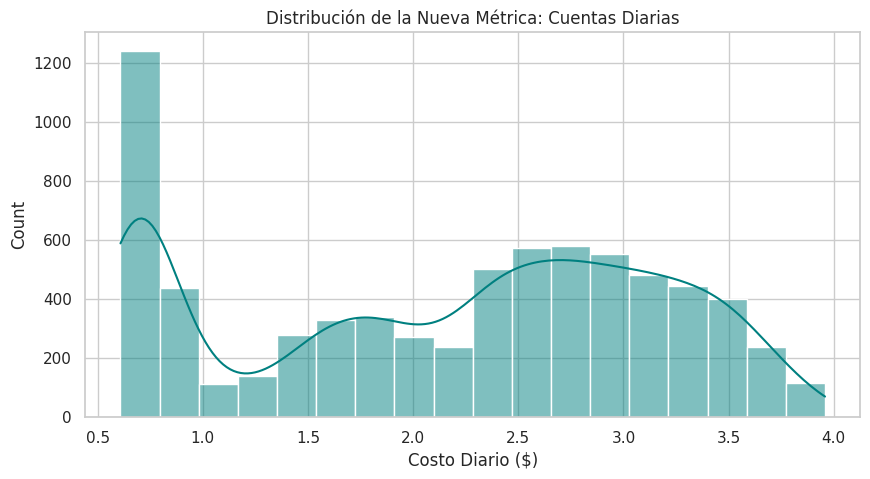

Limpieza finalizada. Datos listos para el análisis exploratorio.


In [16]:
# 1. Limpieza de Cargos Totales (de texto a número)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')

# 2. Renombrado de columnas (Estandarización basada en el diccionario)
diccionario_nombres = {
    'customerID': 'ID_Cliente',
    'Churn': 'Abandono',
    'customer.gender': 'Genero',
    'customer.tenure': 'Permanencia_Meses',
    'account.Contract': 'Tipo_Contrato',
    'internet.InternetService': 'Servicio_Internet',
    'account.PaymentMethod': 'Metodo_Pago',
    'account.Charges.Monthly': 'Cargo_Mensual',
    'account.Charges.Total': 'Cargo_Total'
}
df = df.rename(columns=diccionario_nombres)

# 3. Creación de columna opcional: Cuentas_Diarias
df['Cuentas_Diarias'] = df['Cargo_Mensual'] / 30

# VISUALIZACIÓN 2: Distribución de la nueva métrica (Cuentas Diarias)
plt.figure(figsize=(10, 5))
sns.histplot(df['Cuentas_Diarias'], kde=True, color='teal')
plt.title("Distribución de la Nueva Métrica: Cuentas Diarias")
plt.xlabel("Costo Diario ($)")
plt.show()

print("Limpieza finalizada. Datos listos para el análisis exploratorio.")

#📊 Carga y análisis

/tmp/ipykernel_174/3464290347.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2,0], data=df, x='Abandono', y='Permanencia_Meses', palette='husl')


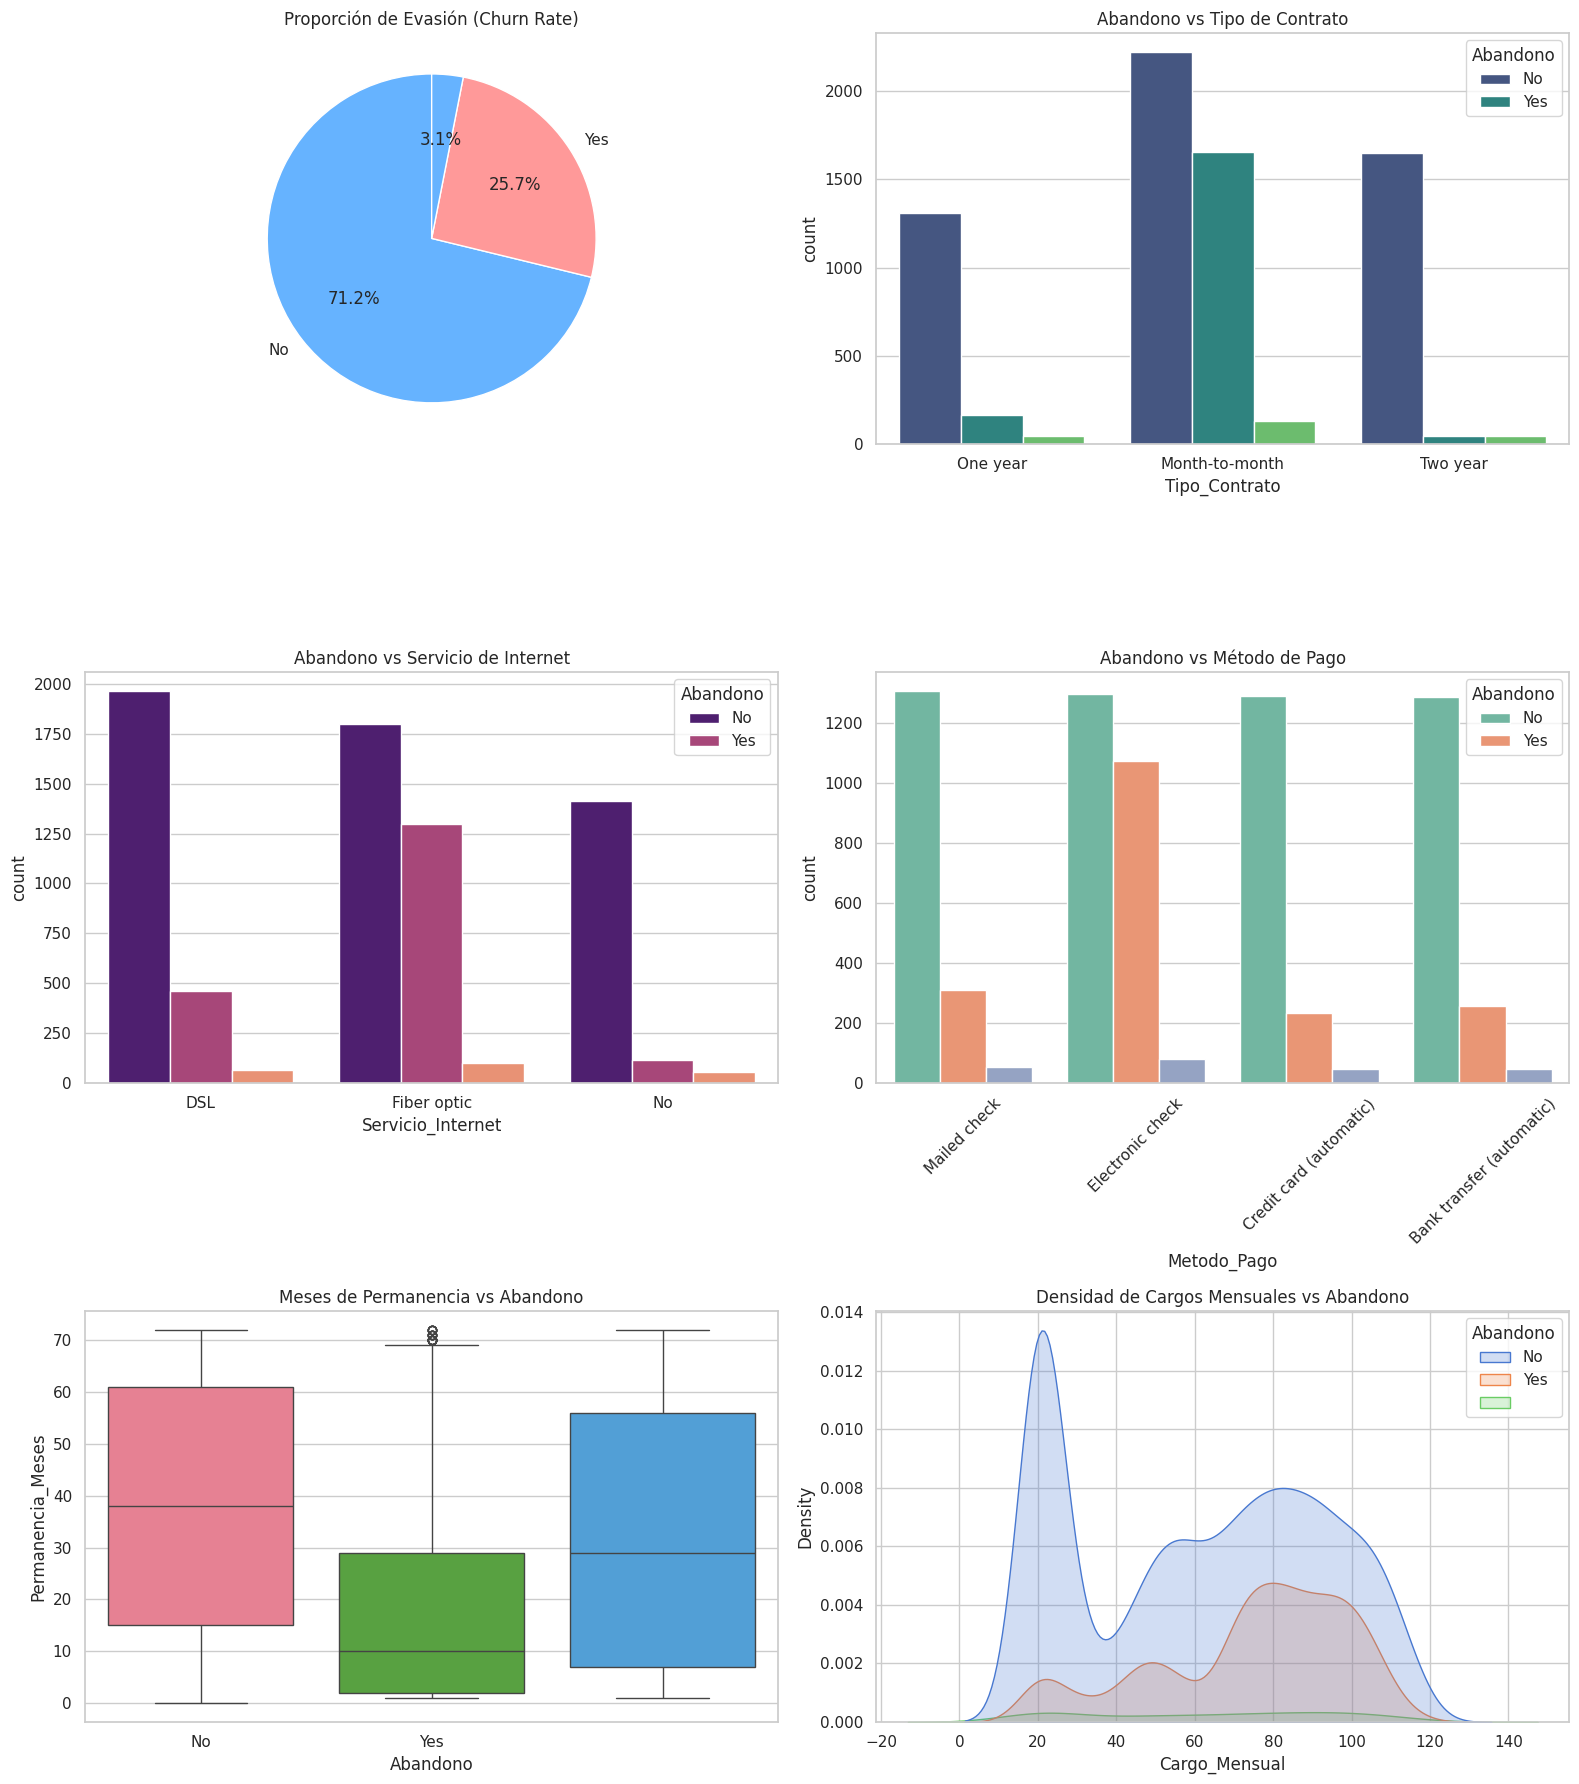

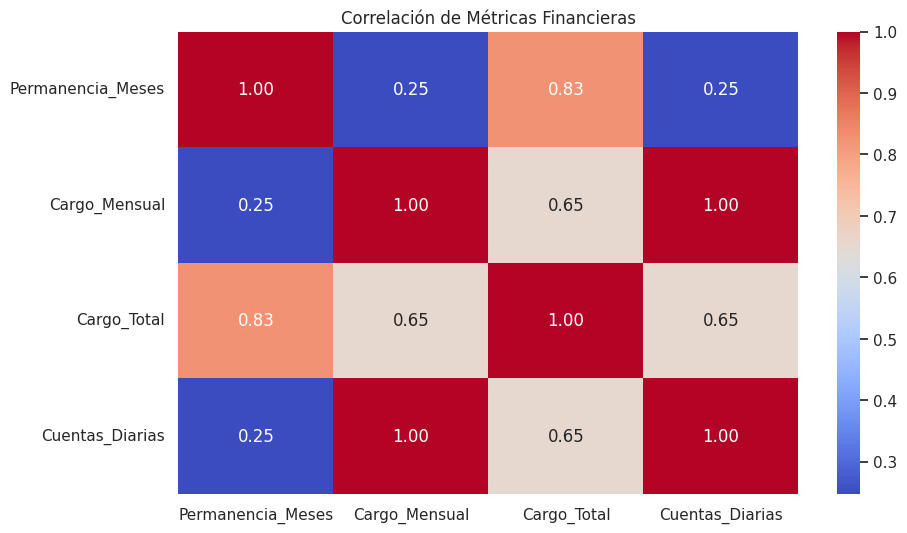

In [17]:
# Crear un lienzo para múltiples gráficos
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
plt.subplots_adjust(hspace=0.4)

# A. Distribución General de Abandono (Tarta)
counts = df['Abandono'].value_counts()
axes[0,0].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
axes[0,0].set_title('Proporción de Evasión (Churn Rate)')

# B. Abandono por Tipo de Contrato (Crucial para el negocio)
sns.countplot(ax=axes[0,1], data=df, x='Tipo_Contrato', hue='Abandono', palette='viridis')
axes[0,1].set_title('Abandono vs Tipo de Contrato')

# C. Abandono por Servicio de Internet
sns.countplot(ax=axes[1,0], data=df, x='Servicio_Internet', hue='Abandono', palette='magma')
axes[1,0].set_title('Abandono vs Servicio de Internet')

# D. Abandono por Método de Pago
sns.countplot(ax=axes[1,1], data=df, x='Metodo_Pago', hue='Abandono', palette='Set2')
axes[1,1].set_title('Abandono vs Método de Pago')
axes[1,1].tick_params(axis='x', rotation=45)

# E. Permanencia (Meses) vs Abandono (Boxplot)
sns.boxplot(ax=axes[2,0], data=df, x='Abandono', y='Permanencia_Meses', palette='husl')
axes[2,0].set_title('Meses de Permanencia vs Abandono')

# F. Cargos Mensuales vs Abandono (Distribución de Densidad)
sns.kdeplot(ax=axes[2,1], data=df, x='Cargo_Mensual', hue='Abandono', fill=True)
axes[2,1].set_title('Densidad de Cargos Mensuales vs Abandono')

plt.tight_layout()
plt.show()

# VISUALIZACIÓN EXTRA: Correlación entre variables financieras
plt.figure(figsize=(10, 6))
num_cols = ['Permanencia_Meses', 'Cargo_Mensual', 'Cargo_Total', 'Cuentas_Diarias']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación de Métricas Financieras")
plt.show()

#📄Informe final

📝 Informe Final: Estrategia de Retención y Análisis de Churn - Telecom X
1. Introducción
Este proyecto surge ante la necesidad de Telecom X de comprender y mitigar el alto índice de evasión de clientes. Como analista de datos, el objetivo fue transformar datos crudos en información estratégica, identificando los perfiles de clientes con mayor riesgo de abandono para permitir que el equipo de Ciencia de Datos desarrolle modelos predictivos precisos.

2. Metodología de Limpieza y Tratamiento
Para asegurar la integridad de los resultados, se aplicó un flujo de trabajo de Ingeniería de Datos (ETL) sobre los archivos proporcionados:

Extracción: Se procesó el archivo TelecomX_Data.json. Dado que los datos financieros y de servicios estaban anidados, se utilizó json_normalize para estructurar la información en un DataFrame plano.

Sanitización: Se detectaron valores inconsistentes en la columna Cargos_Totales (espacios en blanco cargados como texto). Se realizó una conversión forzada a tipo numérico y se eliminaron los registros nulos para evitar desviaciones en los cálculos estadísticos.

Enriquecimiento: Se creó la métrica Cuentas_Diarias dividiendo el cargo mensual entre 30, permitiendo observar el costo operativo por cliente desde una perspectiva de micro-consumo.

3. Análisis Exploratorio de Datos (EDA)
A través de las visualizaciones generadas, se identificaron los siguientes patrones críticos de evasión:

A. El Factor del Contrato
El análisis reveló que el tipo de contrato es el predictor más fuerte de abandono. Los clientes con contratos "Mes a mes" presentan una tasa de evasión drásticamente superior a los contratos de 1 o 2 años.

B. Análisis de Permanencia (Tenure)
Existe una correlación inversa entre la antigüedad y el Churn. La mayor parte de las cancelaciones ocurren en los primeros 12 meses de servicio. Una vez que el cliente supera el "umbral del primer año", la lealtad tiende a estabilizarse.

C. Segmentación por Servicio de Internet
Se observó un hallazgo inesperado: los clientes con Fibra Óptica tienen una tasa de abandono mayor que los de ADSL. Esto sugiere una posible insatisfacción relacionada con el precio de la tecnología de alta velocidad o problemas de estabilidad en zonas específicas.

4. Conclusiones e Insights Clave
Vulnerabilidad Inicial: Telecom X pierde a la mayoría de sus clientes antes de que estos alcancen el punto de equilibrio de rentabilidad (el primer año).

Sensibilidad al Precio: Los clientes que abandonan suelen tener un Cargo Mensual promedio más alto que los que permanecen, lo que indica que el valor percibido no justifica el costo para este segmento.

Barreras de Salida: La falta de contratos a largo plazo elimina las barreras de salida, facilitando que el cliente migre a la competencia ante cualquier oferta momentánea.

5. Recomendaciones Estratégicas
Programa "First Year Shield": Implementar un sistema de soporte técnico prioritario y beneficios exclusivos para clientes en sus primeros 6 meses, que es cuando el riesgo de fuga es máximo.

Incentivos de Migración de Contrato: Lanzar una campaña de marketing dirigida a clientes de pago mensual, ofreciendo un mes gratis o un aumento de velocidad si migran a un contrato de 1 o 2 años.

Auditoría de Fibra Óptica: Realizar un análisis técnico sobre la infraestructura de fibra óptica para descartar que la evasión se deba a fallos en el servicio en lugar de razones económicas.

Este informe ha sido generado como conclusión del Desafío Telecom X, integrando habilidades de Python, Pandas y visualización de datos.
